#  Prevendo Emissões de CO₂ com Regressão Linear

**Projeto de Machine Learning — Regressão Supervisionada**

##  Objetivo
Construir um modelo de **Regressão Linear Simples** para estimar as emissões de CO₂ de veículos a partir do tamanho do motor (`ENGINESIZE`).

Anotar minhas observaçõos para que se torne um material de estudo.

### Pergunta de negócio
> Existe uma relação linear útil entre o tamanho do motor e as emissões de CO₂?

### Dataset
O conjunto de dados contém informações sobre consumo de combustível e emissões de veículos. A fonte original é o **Open Government Canada**, disponibilizada para fins educacionais pelo curso utilizado como referência.

**Target:** `CO2EMISSIONS` (g/km)  
**Feature principal:** `ENGINESIZE`

##  Tecnologias

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Regressão Linear
- Train/Test Split
- MAE, MSE, RMSE e R²

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("default")

## 1. Carregamento e inspeção dos dados

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

df = pd.read_csv(url)

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
df.head()

Linhas: 1,067
Colunas: 13


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   str    
 2   MODEL                     1067 non-null   str    
 3   VEHICLECLASS              1067 non-null   str    
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   str    
 7   FUELTYPE                  1067 non-null   str    
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 108.5 KB


In [4]:
df[["ENGINESIZE", "CO2EMISSIONS"]].describe().round(2)

,ENGINESIZE,CO2EMISSIONS
count,1067.00,1067.00
mean,3.35,256.23
std,1.42,63.37
min,1.00,108.00
25%,2.00,207.00
50%,3.40,251.00
75%,4.30,294.00
max,8.40,488.00


## 2. Análise exploratória

Antes de treinar o modelo, vamos visualizar a relação entre o tamanho do motor e as emissões de CO₂.

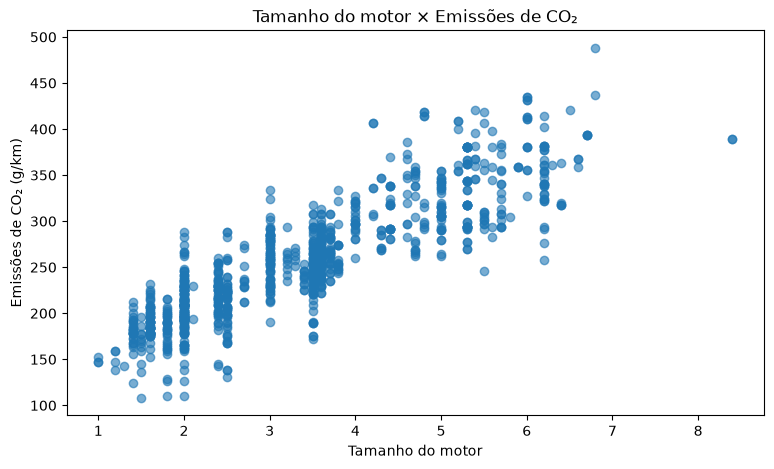

In [5]:
plt.figure(figsize=(9, 5))
plt.scatter(df["ENGINESIZE"], df["CO2EMISSIONS"], alpha=0.6)
plt.xlabel("Tamanho do motor")
plt.ylabel("Emissões de CO₂ (g/km)")
plt.title("Tamanho do motor × Emissões de CO₂")
plt.show()

### Insight inicial

A visualização permite verificar se os pontos apresentam uma tendência aproximadamente linear. Essa análise orienta a escolha de um primeiro modelo, mas não garante que a relação seja perfeitamente linear.

## 3. Preparação dos dados

Vamos utilizar `ENGINESIZE` como variável independente (`X`) e `CO2EMISSIONS` como variável alvo (`y`). O conjunto será dividido em **80% para treinamento e 20% para teste**.

In [6]:
X = df[["ENGINESIZE"]]
y = df["CO2EMISSIONS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (853, 1)
Teste: (214, 1)


## 4. Treinamento do modelo

A Regressão Linear procura encontrar uma reta que minimize o erro entre os valores observados e os valores previstos.

**Equação:**

`ŷ = β₀ + β₁X`

- `β₀`: intercepto
- `β₁`: coeficiente da variável
- `ŷ`: previsão do modelo

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coeficiente: {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Coeficiente: 38.99
Intercepto: 126.29


## 5. Avaliação

Serão utilizadas quatro métricas:

- **MAE:** erro absoluto médio.
- **MSE:** média dos erros ao quadrado.
- **RMSE:** raiz do MSE, na mesma unidade do target.
- **R²:** proporção da variabilidade explicada pelo modelo.

In [8]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Valor": [mae, mse, rmse, r2]
})

metrics.round(3)

,Métrica,Valor
0,MAE,24.097
1,MSE,985.938
2,RMSE,31.400
3,R²,0.762


## 6. Visualização das previsões

c:\Users\Lucas\.virtualenvs\Lucas-7ayU_ma_\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


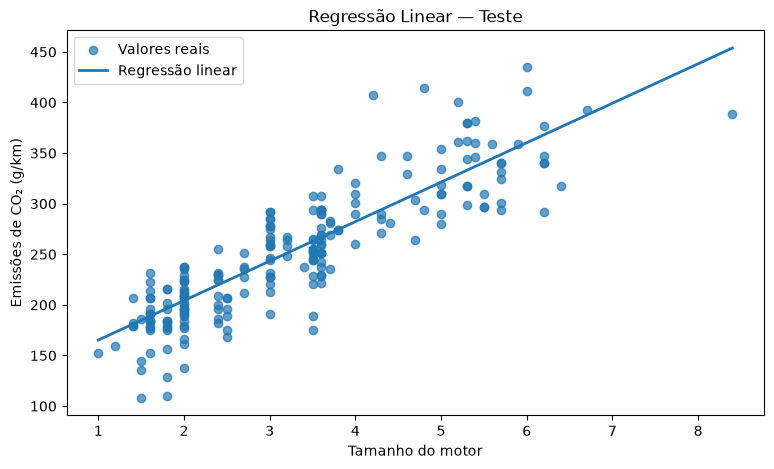

In [9]:
x_line = np.linspace(X["ENGINESIZE"].min(), X["ENGINESIZE"].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(9, 5))
plt.scatter(X_test["ENGINESIZE"], y_test, alpha=0.7, label="Valores reais")
plt.plot(x_line, y_line, linewidth=2, label="Regressão linear")
plt.xlabel("Tamanho do motor")
plt.ylabel("Emissões de CO₂ (g/km)")
plt.title("Regressão Linear — Teste")
plt.legend()
plt.show()

## 7. Conclusões

### O que foi aprendido
- Como estruturar um problema de regressão supervisionada.
- Como separar dados de treino e teste.
- Como treinar uma Regressão Linear com Scikit-learn.
- Como interpretar coeficiente e intercepto.
- Como avaliar o modelo com MAE, MSE, RMSE e R².

### Próximos passos
Apenas o tamanho do motor pode não explicar toda a variação das emissões. Uma evolução natural é adicionar outras variáveis, como consumo de combustível e número de cilindros, e comparar o desempenho com uma **Regressão Linear Múltipla**.

> **Nota de reprodutibilidade:** o `random_state=42` foi utilizado para manter a mesma divisão entre treino e teste em diferentes execuções.

##  Referências

- Dataset: Open Government Canada — Fuel Consumption Ratings.
- Implementação: Scikit-learn.
